In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_url = (
    "https://raw.githubusercontent.com/"
    "JediNoahMio65/"
    "wearable-heart-rate-manufacturing-quality-dashboard/"
    "main/data/synthetic_manufacturing_data.csv"
)

df = pd.read_csv(csv_url, parse_dates=["build_date"])

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 2,400
Columns: 12


,unit_id,build_date,production_line,shift,test_station,firmware_version,heart_rate_error_bpm,response_time_seconds,signal_quality_score,test_status,defect_category,rework_required
0,WHRM-00001,2026-07-01,Line A,Day,TS-01,FW-SIM-0.2,0.76,3.81,95.0,Pass,NaN,No
1,WHRM-00002,2026-07-01,Line A,Evening,TS-01,FW-SIM-0.2,4.25,3.77,92.1,Pass,NaN,No
2,WHRM-00003,2026-07-01,Line A,Evening,TS-02,FW-SIM-0.2,3.42,5.00,94.4,Pass,NaN,No
3,WHRM-00004,2026-07-01,Line B,Day,TS-03,FW-SIM-0.2,1.93,4.11,94.2,Pass,NaN,No
4,WHRM-00005,2026-07-01,Line A,Evening,TS-01,FW-SIM-0.2,0.91,5.18,89.0,Fail,Slow response time,Yes


In [2]:
print("Missing values by column:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate unit IDs:")
print(df["unit_id"].duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("data_type"))

Missing values by column:


,missing_values
unit_id,0
build_date,0
production_line,0
shift,0
test_station,0
firmware_version,0
heart_rate_error_bpm,0
response_time_seconds,0
signal_quality_score,0
test_status,0



Duplicate unit IDs:
0

Data types:


,data_type
unit_id,object
build_date,datetime64[ns]
production_line,object
shift,object
test_station,object
firmware_version,object
heart_rate_error_bpm,float64
response_time_seconds,float64
signal_quality_score,float64
test_status,object


In [3]:
total_units = len(df)
passed_units = (df["test_status"] == "Pass").sum()
failed_units = (df["test_status"] == "Fail").sum()
rework_units = (df["rework_required"] == "Yes").sum()

first_pass_yield = passed_units / total_units
failure_rate = failed_units / total_units
rework_rate = rework_units / total_units

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total units tested",
        "Units passed",
        "Units failed",
        "First-pass yield",
        "Failure rate",
        "Rework rate"
    ],
    "Value": [
        f"{total_units:,}",
        f"{passed_units:,}",
        f"{failed_units:,}",
        f"{first_pass_yield:.1%}",
        f"{failure_rate:.1%}",
        f"{rework_rate:.1%}"
    ]
})

display(kpi_summary)

,Metric,Value
0,Total units tested,"2,400"
1,Units passed,"1,906"
2,Units failed,494
3,First-pass yield,79.4%
4,Failure rate,20.6%
5,Rework rate,15.0%


In [4]:
line_summary = (
    df.assign(passed=df["test_status"].eq("Pass"))
      .groupby("production_line", as_index=False)
      .agg(
          units_tested=("unit_id", "count"),
          passed_units=("passed", "sum"),
          mean_hr_error_bpm=("heart_rate_error_bpm", "mean"),
          mean_response_time_s=("response_time_seconds", "mean"),
          mean_signal_quality=("signal_quality_score", "mean")
      )
)

line_summary["first_pass_yield"] = (
    line_summary["passed_units"] / line_summary["units_tested"]
)

station_summary = (
    df.assign(passed=df["test_status"].eq("Pass"))
      .groupby("test_station", as_index=False)
      .agg(
          units_tested=("unit_id", "count"),
          passed_units=("passed", "sum"),
          mean_hr_error_bpm=("heart_rate_error_bpm", "mean"),
          mean_response_time_s=("response_time_seconds", "mean"),
          mean_signal_quality=("signal_quality_score", "mean")
      )
)

station_summary["first_pass_yield"] = (
    station_summary["passed_units"] / station_summary["units_tested"]
)

print("Quality by production line")
display(
    line_summary.style.format({
        "first_pass_yield": "{:.1%}",
        "mean_hr_error_bpm": "{:.2f}",
        "mean_response_time_s": "{:.2f}",
        "mean_signal_quality": "{:.1f}"
    })
)

print("Quality by test station")
display(
    station_summary.style.format({
        "first_pass_yield": "{:.1%}",
        "mean_hr_error_bpm": "{:.2f}",
        "mean_response_time_s": "{:.2f}",
        "mean_signal_quality": "{:.1f}"
    })
)

Quality by production line


,production_line,units_tested,passed_units,mean_hr_error_bpm,mean_response_time_s,mean_signal_quality,first_pass_yield
0,Line A,1015,837,2.43,4.08,90.8,82.5%
1,Line B,810,615,2.96,4.09,90.4,75.9%
2,Line C,575,454,2.46,4.10,90.2,79.0%


Quality by test station


,test_station,units_tested,passed_units,mean_hr_error_bpm,mean_response_time_s,mean_signal_quality,first_pass_yield
0,TS-01,970,788,2.64,4.09,91.6,81.2%
1,TS-02,818,660,2.65,4.06,91.1,80.7%
2,TS-03,612,458,2.54,4.11,88.0,74.8%


,defect_category,count,percent_of_defects,cumulative_percent
0,Slow response time,205,41.5%,41.5%
1,Low signal quality,114,23.1%,64.6%
2,High heart-rate error,100,20.2%,84.8%
3,Assembly defect,47,9.5%,94.3%
4,Cosmetic defect,28,5.7%,100.0%


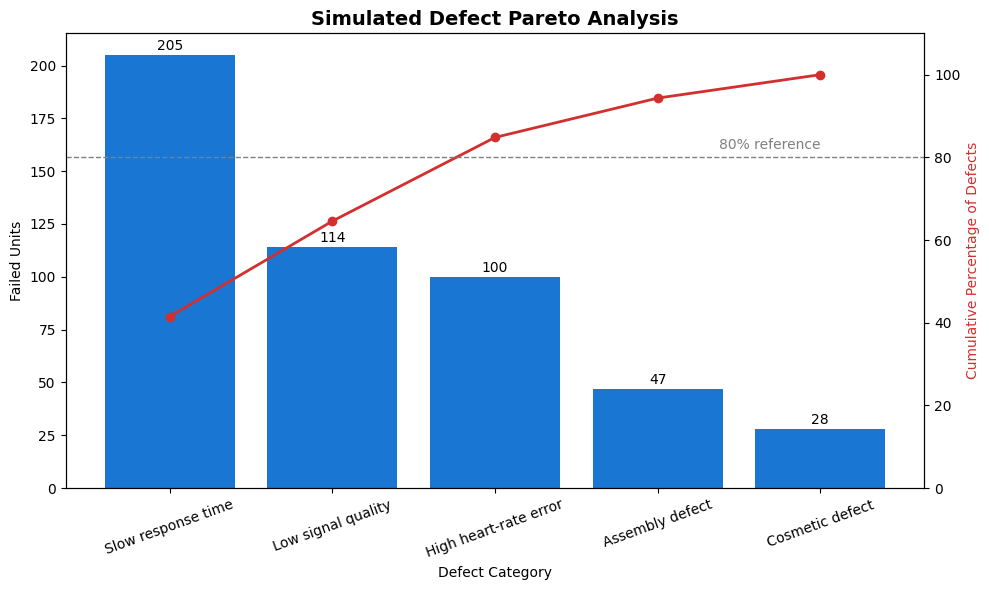

In [5]:
defect_counts = (
    df.loc[df["defect_category"] != "None", "defect_category"]
      .value_counts()
      .sort_values(ascending=False)
)

pareto = defect_counts.reset_index()
pareto.columns = ["defect_category", "count"]
pareto["percent_of_defects"] = pareto["count"] / pareto["count"].sum()
pareto["cumulative_percent"] = pareto["percent_of_defects"].cumsum()

display(
    pareto.style.format({
        "percent_of_defects": "{:.1%}",
        "cumulative_percent": "{:.1%}"
    })
)

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(
    pareto["defect_category"],
    pareto["count"],
    color="#1976D2"
)

ax1.set_title("Simulated Defect Pareto Analysis", fontsize=14, weight="bold")
ax1.set_xlabel("Defect Category")
ax1.set_ylabel("Failed Units")
ax1.tick_params(axis="x", rotation=20)

for bar, count in zip(bars, pareto["count"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha="center",
        va="bottom"
    )

ax2 = ax1.twinx()
ax2.plot(
    pareto["defect_category"],
    pareto["cumulative_percent"] * 100,
    color="#D32F2F",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Cumulative Percentage of Defects", color="#D32F2F")
ax2.set_ylim(0, 110)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.text(
    len(pareto) - 1,
    82,
    "80% reference",
    color="gray",
    ha="right"
)

plt.tight_layout()
plt.savefig("defect_pareto.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
lowest_yield_line = line_summary.loc[
    line_summary["first_pass_yield"].idxmin()
]

lowest_yield_station = station_summary.loc[
    station_summary["first_pass_yield"].idxmin()
]

top_defect = pareto.iloc[0]

print("SIMULATED QUALITY FINDINGS")
print(
    f"- Overall first-pass yield: {first_pass_yield:.1%} "
    f"({passed_units:,} of {total_units:,} units)."
)
print(
    f"- Lowest-yield production line: {lowest_yield_line['production_line']} "
    f"at {lowest_yield_line['first_pass_yield']:.1%}."
)
print(
    f"- Lowest-yield test station: {lowest_yield_station['test_station']} "
    f"at {lowest_yield_station['first_pass_yield']:.1%}."
)
print(
    f"- Most common defect category: {top_defect['defect_category']} "
    f"({top_defect['count']} failed units; "
    f"{top_defect['percent_of_defects']:.1%} of all failures)."
)

SIMULATED QUALITY FINDINGS
- Overall first-pass yield: 79.4% (1,906 of 2,400 units).
- Lowest-yield production line: Line B at 75.9%.
- Lowest-yield test station: TS-03 at 74.8%.
- Most common defect category: Slow response time (205 failed units; 41.5% of all failures).
